<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350855055" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<style>
.rf-wrap { font-family: Arial, Helvetica, sans-serif; color: #eee; }
.rf-card { background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 20px 24px; margin: 18px 0; }
.rf-muted { color: #c4b5fd; }
.rf-body { color: #d8b4fe; font-size: 13px; line-height: 1.7; }
.rf-grid-2 { display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }
.rf-grid-3 { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; }
.rf-pill { display: inline-block; background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 4px 11px; border-radius: 20px; text-transform: uppercase; }
.rf-accent { color: #a855f7; }
.rf-code { background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 8px; padding: 12px 16px; }
.rf-note { background: #12002a; border-left: 5px solid #a855f7; border-radius: 0 10px 10px 0; padding: 16px 20px; margin: 18px 0; color: #d8b4fe; font-size: 13px; line-height: 1.7; }
.rf-section { border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0; }
.rf-section h2 { color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0; }
.rf-kicker { color: #c4b5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px; }
@media (max-width: 760px) {
  .rf-grid-2, .rf-grid-3 { grid-template-columns: 1fr; }
}
</style>

<div class="rf-wrap" style="background: linear-gradient(135deg, #1a0030 0%, #2d0050 50%, #1a0040 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #4a0080;">
  <span class="rf-pill">ML Series · Episode 49</span>
  <h1 style="color:#fff; font-size:38px; font-weight:800; margin:16px 0 12px 0; line-height:1.2;">🌲 Random Forest</h1>
  <p style="color:#d8b4fe; font-size:16px; margin:0 0 8px 0; font-style:italic;">“Many different trees. One stronger prediction.”</p>
  <p style="color:#c4b5fd; font-size:15px; margin:0 0 28px 0; max-width:720px; line-height:1.6;">
    From bootstrap sampling and random feature selection to voting, OOB evaluation, hyperparameter tuning, and feature importance.
  </p>
  <div class="rf-grid-3">
    <div style="background:rgba(255,255,255,0.06); border:1px solid #4a0080; border-radius:10px; padding:14px 20px;">
      <div style="color:#a855f7; font-size:20px; font-weight:700;">Bootstrap</div>
      <div style="color:#d8b4fe; font-size:12px; margin-top:2px;">Different training samples</div>
    </div>
    <div style="background:rgba(255,255,255,0.06); border:1px solid #4a0080; border-radius:10px; padding:14px 20px;">
      <div style="color:#a855f7; font-size:20px; font-weight:700;">Random Features</div>
      <div style="color:#d8b4fe; font-size:12px; margin-top:2px;">More tree diversity</div>
    </div>
    <div style="background:rgba(255,255,255,0.06); border:1px solid #4a0080; border-radius:10px; padding:14px 20px;">
      <div style="color:#a855f7; font-size:20px; font-weight:700;">Ensemble</div>
      <div style="color:#d8b4fe; font-size:12px; margin-top:2px;">Vote or average predictions</div>
    </div>
  </div>
</div>



<div class="rf-wrap" style="background:#0d0020; border-left:5px solid #a855f7; border-radius:0 10px 10px 0; padding:20px 24px; margin:24px 0; border:1px solid #4a0080; border-left:5px solid #a855f7;">
  <h2 style="color:#a855f7; font-size:15px; font-weight:700; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:4px;">
    <ol style="margin:0; padding-left:20px; color:#c084fc; line-height:2.05; font-size:14px;">
      <li><a href="#intro" style="color:#c084fc; text-decoration:none;">What is Random Forest?</a></li>
      <li><a href="#intuition" style="color:#c084fc; text-decoration:none;">The Core Intuition</a></li>
      <li><a href="#sampling" style="color:#c084fc; text-decoration:none;">Bootstrap &amp; Feature Sampling</a></li>
      <li><a href="#trees" style="color:#c084fc; text-decoration:none;">Building Multiple Trees</a></li>
      <li><a href="#classification" style="color:#c084fc; text-decoration:none;">Classification Demo</a></li>
      <li><a href="#regression" style="color:#c084fc; text-decoration:none;">Regression Demo</a></li>
      <li><a href="#bagging" style="color:#c084fc; text-decoration:none;">Bagging vs Random Forest</a></li>
    </ol>
    <ol start="8" style="margin:0; padding-left:20px; color:#c084fc; line-height:2.05; font-size:14px;">
      <li><a href="#tuning" style="color:#c084fc; text-decoration:none;">Hyperparameter Tuning</a></li>
      <li><a href="#grid" style="color:#c084fc; text-decoration:none;">GridSearchCV</a></li>
      <li><a href="#random-search" style="color:#c084fc; text-decoration:none;">RandomizedSearchCV</a></li>
      <li><a href="#oob" style="color:#c084fc; text-decoration:none;">OOB Score</a></li>
      <li><a href="#importance" style="color:#c084fc; text-decoration:none;">Feature Importance</a></li>
      <li><a href="#importance-math" style="color:#c084fc; text-decoration:none;">How Feature Importance Is Calculated</a></li>
      <li><a href="#takeaways" style="color:#c084fc; text-decoration:none;">Key Concepts &amp; Takeaways</a></li>
    </ol>
  </div>
</div>


<a id="intro"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 1</span>
  <h2> 📌 What is Random Forest?</h2>
</div>

**Random Forest** is an ensemble learning algorithm that combines many decision trees into a single model.

A Random Forest deliberately introduces randomness in two places:

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:7px;">🌱 Bootstrap samples</div>
    <div class="rf-body">Each tree can be trained on a different sample of the training rows, drawn <strong style="color:#f0e6ff;">with replacement</strong>.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:7px;">🎲 Random feature subsets</div>
    <div class="rf-body">At each decision-tree split, only a random subset of the available features is considered.</div>
  </div>
</div>

The forest then combines the trees:

<div class="rf-card" style="text-align:center;">
  <div style="color:#f0e6ff;font-size:17px;font-weight:700;">🌳 + 🌳 + 🌳 + ... + 🌳 → 🌲 Random Forest</div>
  <div class="rf-body" style="margin-top:7px;">Classification → aggregate by voting &nbsp;•&nbsp; Regression → aggregate by averaging</div>
</div>

<div class="rf-note"><strong style="color:#a855f7;">Core idea →</strong> Randomness creates diverse trees; aggregation makes the final model less dependent on the quirks of any one tree.</div>


<a id="intuition"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 2</span>
  <h2> 🧠 The Core Intuition</h2>
</div>

### 🎯 Before the code

Imagine one decision tree makes an unstable split because of the exact rows it happened to see.

What happens when we build **many different trees**, each trained from a slightly different view of the data, and then combine their predictions?

<div class="rf-card">
  <div class="rf-kicker">From one model to an ensemble</div>
  <div class="rf-grid-3">
    <div style="text-align:center;border:1px solid #4a0080;border-radius:8px;padding:15px;">
      <div style="font-size:24px;">🌳</div>
      <div style="color:#a855f7;font-weight:700;font-size:13px;">Single Tree</div>
      <div class="rf-body">Sensitive to the particular training samples and splits it receives.</div>
    </div>
    <div style="text-align:center;border:1px solid #a855f7;border-radius:8px;padding:15px;">
      <div style="font-size:24px;">🌲🌲🌲</div>
      <div style="color:#a855f7;font-weight:700;font-size:13px;">Diverse Trees</div>
      <div class="rf-body">Random sampling makes the individual trees less alike.</div>
    </div>
    <div style="text-align:center;border:1px solid #4a0080;border-radius:8px;padding:15px;">
      <div style="font-size:24px;">🗳️</div>
      <div style="color:#a855f7;font-weight:700;font-size:13px;">Aggregate</div>
      <div class="rf-body">The forest votes for a class or averages numerical predictions.</div>
    </div>
  </div>
</div>

The notebook first recreates the **sampling intuition manually**, then uses scikit-learn's Random Forest implementation on classification, regression, tuning, OOB evaluation, and feature importance.


<a id="sampling"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 3</span>
  <h2> 🎲 Bootstrap & Random Feature Sampling</h2>
</div>

The next cells make the two sources of randomness visible before we use `RandomForestClassifier`.

### 1. Bootstrap row sampling

`sample_rows()` selects rows **with replacement**. A row can appear more than once in the resulting training sample, while other original rows may be omitted.

### 2. Random feature sampling

`sample_features()` picks a subset of input columns. This notebook uses it to create different feature views for the manual demonstration.

### 3. Combined sampling

`combined_sampling()` applies both ideas so that each tree can see a different training view.

<div class="rf-note">
<strong style="color:#a855f7;">Important implementation detail →</strong>
The helper functions here are a <strong>simplified teaching demo</strong>. In a true Random Forest, feature randomness is applied at the <strong>tree split/node level</strong> (through <code>max_features</code>), not simply once for the whole tree as in this manual example.
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Reproducibility for the manual sampling demo
random.seed(42)

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import make_classification, make_circles
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.729267,1.435978,0.774577,-1.647935,1.867757,0
1,-0.910081,0.055297,-0.379104,-4.815795,0.754664,0
2,1.584564,0.456023,1.893923,-0.019989,2.370637,0
3,-1.602465,2.335091,1.705626,2.509742,3.212223,1
4,-0.054645,1.286559,1.110962,1.222686,1.321718,1


<a id="sampling-inline"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 4</span>
  <h2> 🔎 Inspecting the Sampled Feature Sets</h2>
</div>

The three generated dataframes should not contain exactly the same feature columns. That visible difference is the point of the demo: **different trees should receive different information**.

The row sampling also uses replacement, so individual bootstrap datasets can contain repeated observations.


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target'].to_numpy()
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df, 0.5, 0.5)

In [8]:
df2 = combined_sampling(df, 0.5, 0.5)

In [9]:
df3 = combined_sampling(df, 0.5, 0.5)

In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col5', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')
Index(['col2', 'col5', 'target'], dtype='object')


In [11]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [12]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.631578947368421, 0.9166666666666666, 'x[0] <= 0.596\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.42105263157894735, 0.75, 'x[1] <= 1.716\ngini = 0.36\nsamples = 34\nvalue = [26, 8]'),
 Text(0.5263157894736842, 0.8333333333333333, 'True  '),
 Text(0.21052631578947367, 0.5833333333333334, 'x[0] <= 0.183\ngini = 0.219\nsamples = 24\nvalue = [21, 3]'),
 Text(0.10526315789473684, 0.4166666666666667, 'x[1] <= 1.026\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.05263157894736842, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.15789473684210525, 0.25, 'x[1] <= 1.103\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.10526315789473684, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21052631578947367, 0.08333333333333333, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.3157894736842105, 0.4166666666666667, 'x[0] <= 0.489\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.2631578947368421, 0.25, 'gini = 0.0\nsamples = 2\

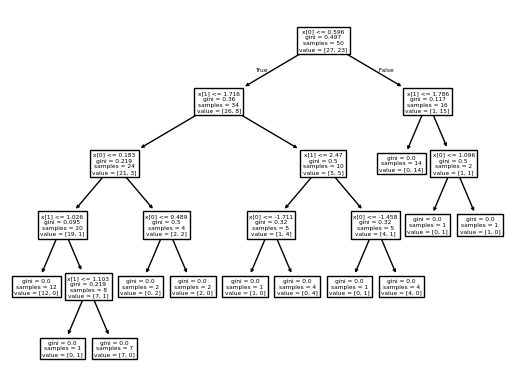

In [13]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.6125, 0.9166666666666666, 'x[0] <= 1.774\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.425, 0.75, 'x[1] <= 2.276\ngini = 0.464\nsamples = 30\nvalue = [11, 19]'),
 Text(0.51875, 0.8333333333333333, 'True  '),
 Text(0.375, 0.5833333333333334, 'x[1] <= 1.082\ngini = 0.499\nsamples = 23\nvalue = [11, 12]'),
 Text(0.2, 0.4166666666666667, 'x[0] <= 0.106\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.1, 0.25, 'x[1] <= 0.685\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.05, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.15, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.25, 'x[1] <= 0.896\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.25, 0.08333333333333333, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.35, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.55, 0.4166666666666667, 'x[1] <= 1.361\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.5, 0.25, 'x[0

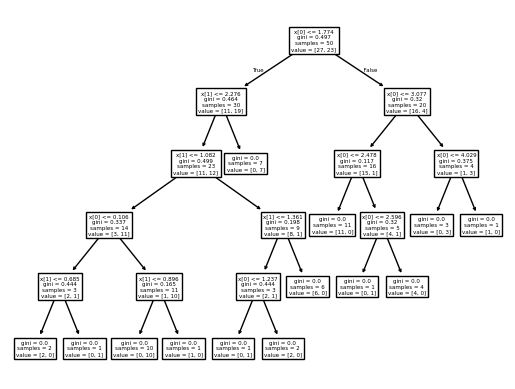

In [14]:
plot_tree(clf2)

[Text(0.375, 0.9375, 'x[0] <= 0.097\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.1111111111111111, 0.8125, 'x[1] <= -0.188\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.24305555555555555, 0.875, 'True  '),
 Text(0.05555555555555555, 0.6875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.6875, 'x[1] <= 0.891\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.1111111111111111, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.2222222222222222, 0.5625, 'x[0] <= 0.059\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.16666666666666666, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2777777777777778, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6388888888888888, 0.8125, 'x[0] <= 1.803\ngini = 0.444\nsamples = 39\nvalue = [13, 26]'),
 Text(0.5069444444444444, 0.875, '  False'),
 Text(0.4444444444444444, 0.6875, 'x[1] <= -0.044\ngini = 0.311\nsamples = 26\nvalue = [5, 21]'),
 Text(0.3888888888888889,

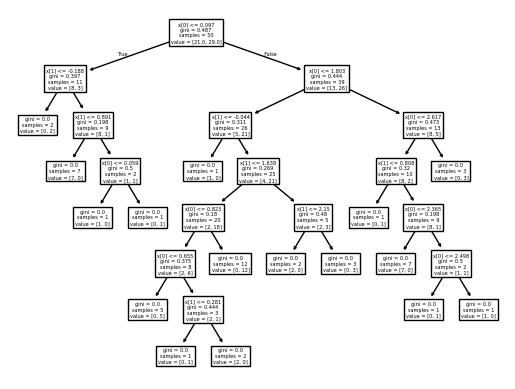

In [15]:
plot_tree(clf3)

In [16]:
df1_input = pd.DataFrame([[-1.042498, -0.064323]], columns=df1.columns[:2])
clf1.predict(df1_input)


array([0])

In [17]:
df2_input = pd.DataFrame([[-1.042498, -0.064323]], columns=df2.columns[:2])
clf2.predict(df2_input)


array([0])

In [18]:
df3_input = pd.DataFrame([[-1.042498, -0.064323]], columns=df3.columns[:2])
clf3.predict(df3_input)


array([0])

<a id="trees"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 5</span>
  <h2> 🌳 Building Multiple Decision Trees</h2>
</div>

Now three decision trees are trained on three different sampled datasets.

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:7px;">🔀 Tree diversity</div>
    <div class="rf-body">Different sampled rows and feature subsets can lead the trees to discover different splits.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:7px;">🗳️ Ensemble intuition</div>
    <div class="rf-body">If the trees disagree on one sample, the ensemble can combine their individual opinions instead of trusting a single tree.</div>
  </div>
</div>

The next cells visualise the individual trees and ask each one to predict the same two-feature input.



<div class="rf-note"><strong style="color:#a855f7;">From trees → forest:</strong> the small voting step below is the essence of classification in an ensemble. A production Random Forest performs this aggregation across many trees rather than only three.</div>


In [19]:
# Aggregate the three tree predictions by majority vote
tree_predictions = [
    int(clf1.predict(df1_input)[0]),
    int(clf2.predict(df2_input)[0]),
    int(clf3.predict(df3_input)[0])
]

forest_prediction = max(set(tree_predictions), key=tree_predictions.count)

print("Individual tree predictions:", tree_predictions)
print("Majority-vote prediction     :", forest_prediction)


Individual tree predictions: [0, 0, 0]
Majority-vote prediction     : 0


<a id="classification"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 6</span>
  <h2> 🧪 Random Forest Classification Demo</h2>
</div>

A `make_circles` dataset gives us a non-linear classification problem that is easy to plot.

We compare a **single Decision Tree** with a **Random Forest containing 500 trees** and visualise both decision boundaries.

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🌳 Decision Tree</div>
    <div class="rf-body">One tree builds one sequence of splits from the training data.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🌲 Random Forest</div>
    <div class="rf-body">Many randomized trees contribute to the final class prediction.</div>
  </div>
</div>

### 👀 What to inspect

Look at the two decision regions. The forest is not a single larger tree—it is an **aggregation of many separate tree predictions**.


In [20]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

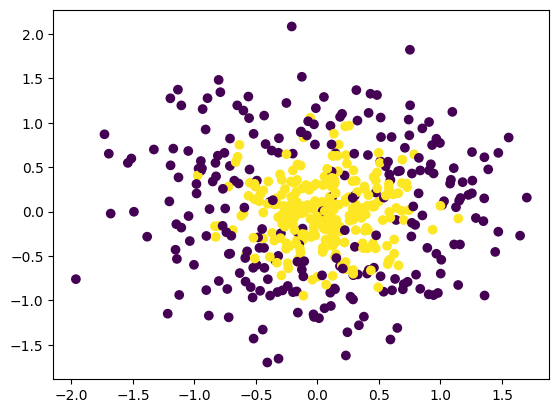

In [21]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

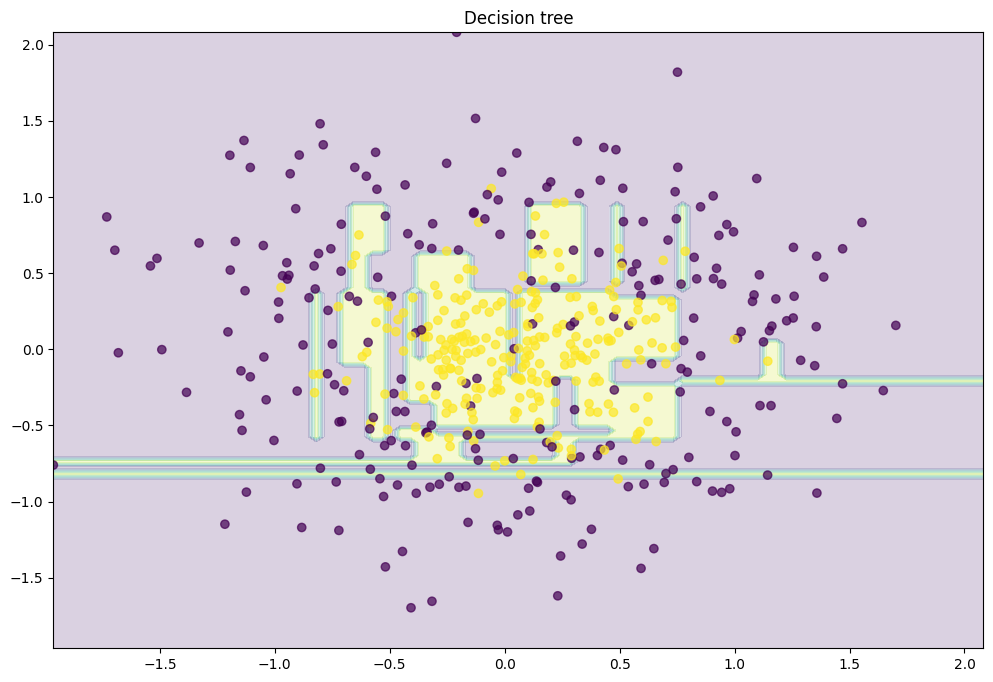

In [22]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

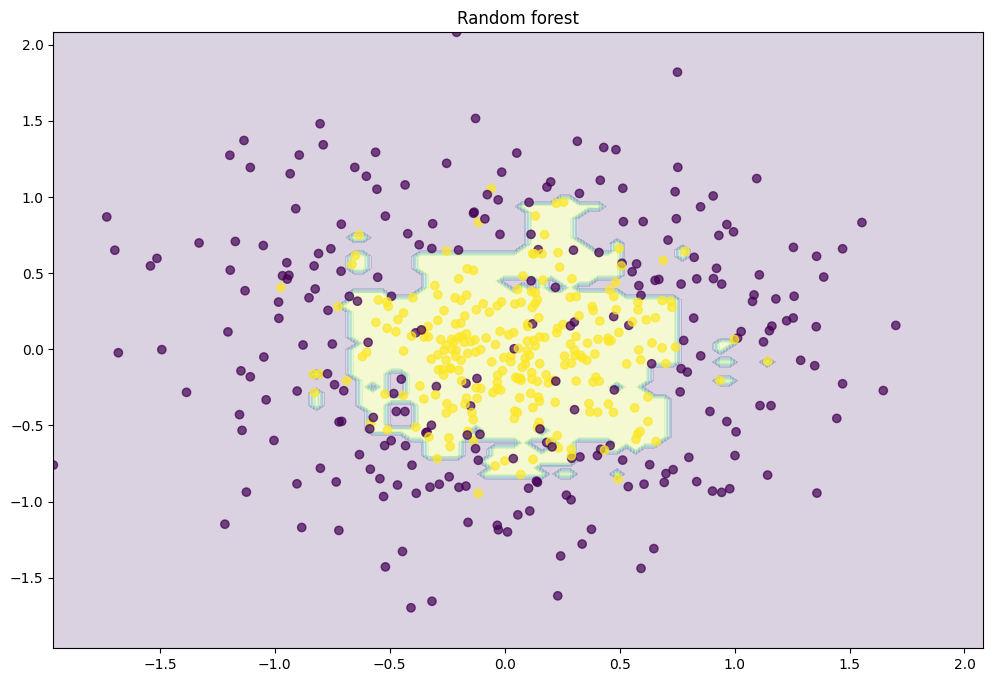

In [23]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

<a id="regression"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 7</span>
  <h2> 📈 Random Forest Regression Demo</h2>
</div>

Random Forest also works for regression.

For a regression problem, each tree outputs a numerical prediction and the forest combines those values, typically by averaging them.

The cells below compare a `DecisionTreeRegressor` and a `RandomForestRegressor` on a noisy non-linear function.

<div class="rf-note"><strong style="color:#a855f7;">Why the plot is useful →</strong> A single tree tends to create a piecewise, sample-specific prediction function. The forest combines many such trees into a smoother aggregate estimate.</div>


In [24]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

In [25]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

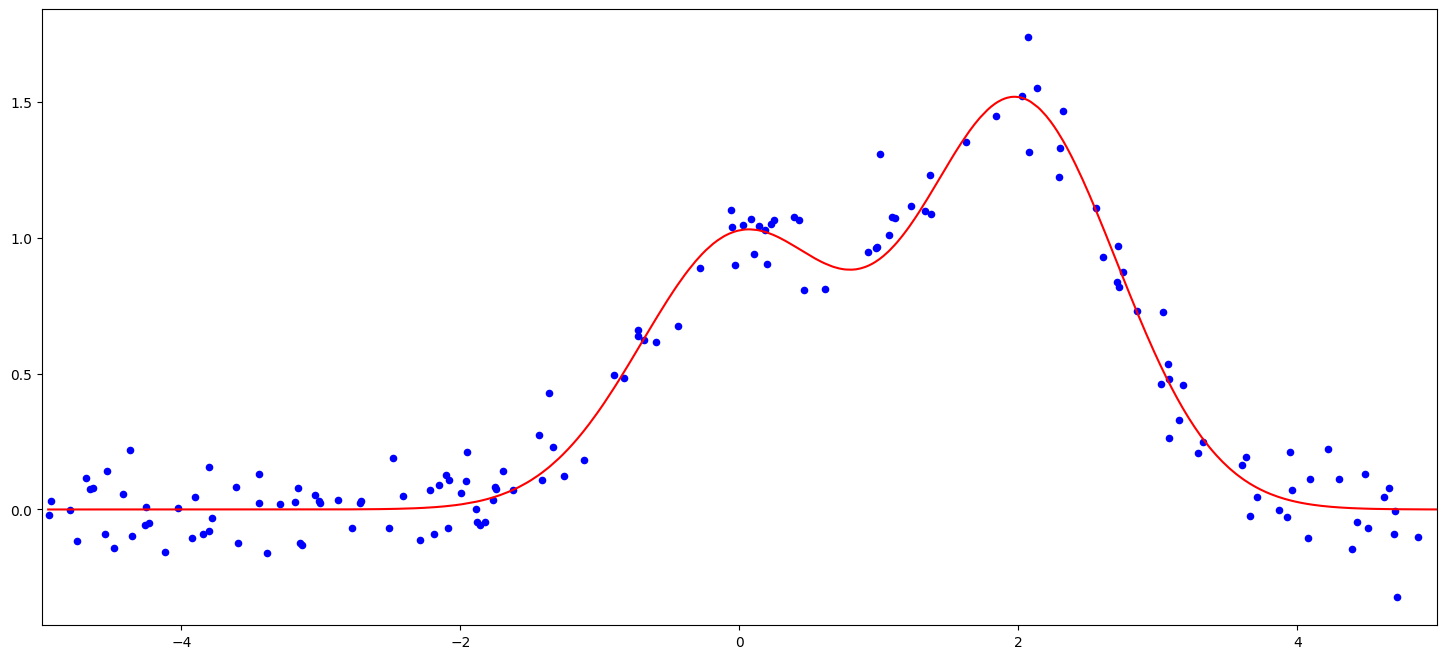

In [26]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
plt.show()

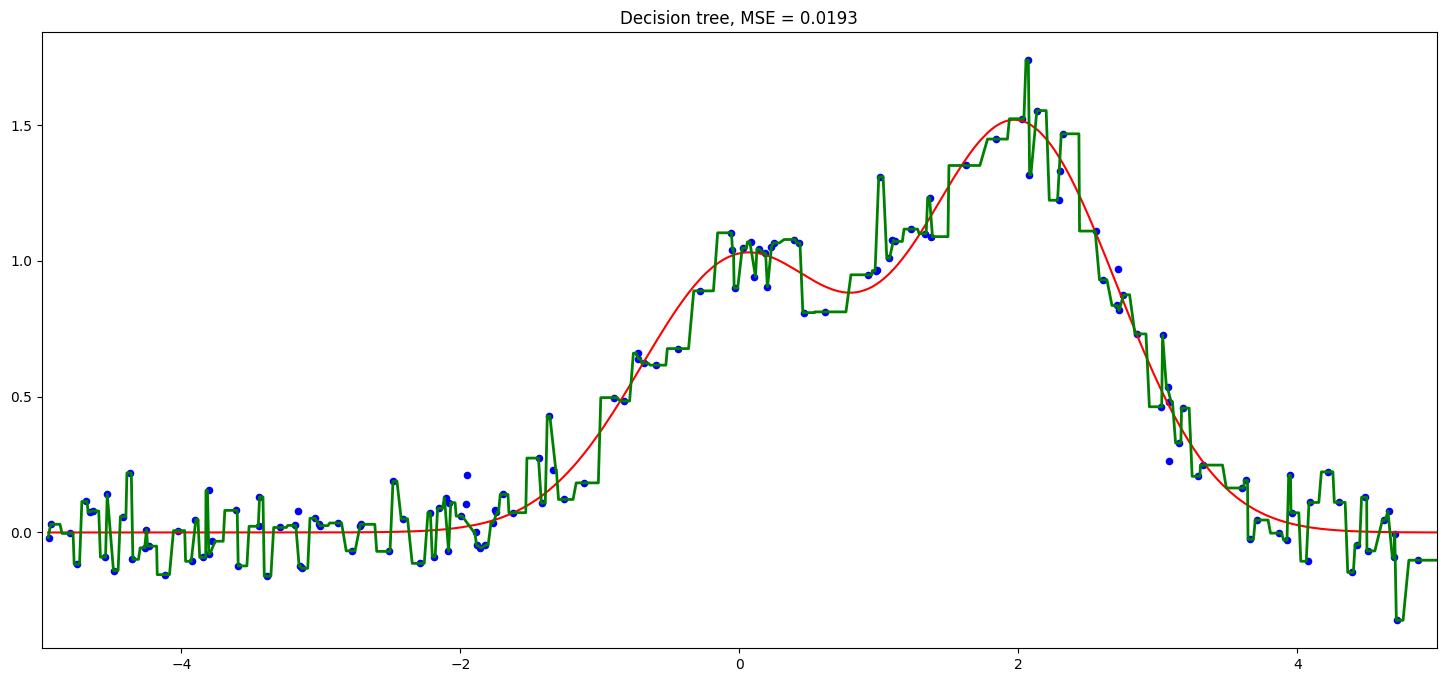

In [27]:
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
mse_dt = np.mean((y_test - d_predict) ** 2)
plt.title("Decision tree, MSE = %.4f" % mse_dt)
plt.show()

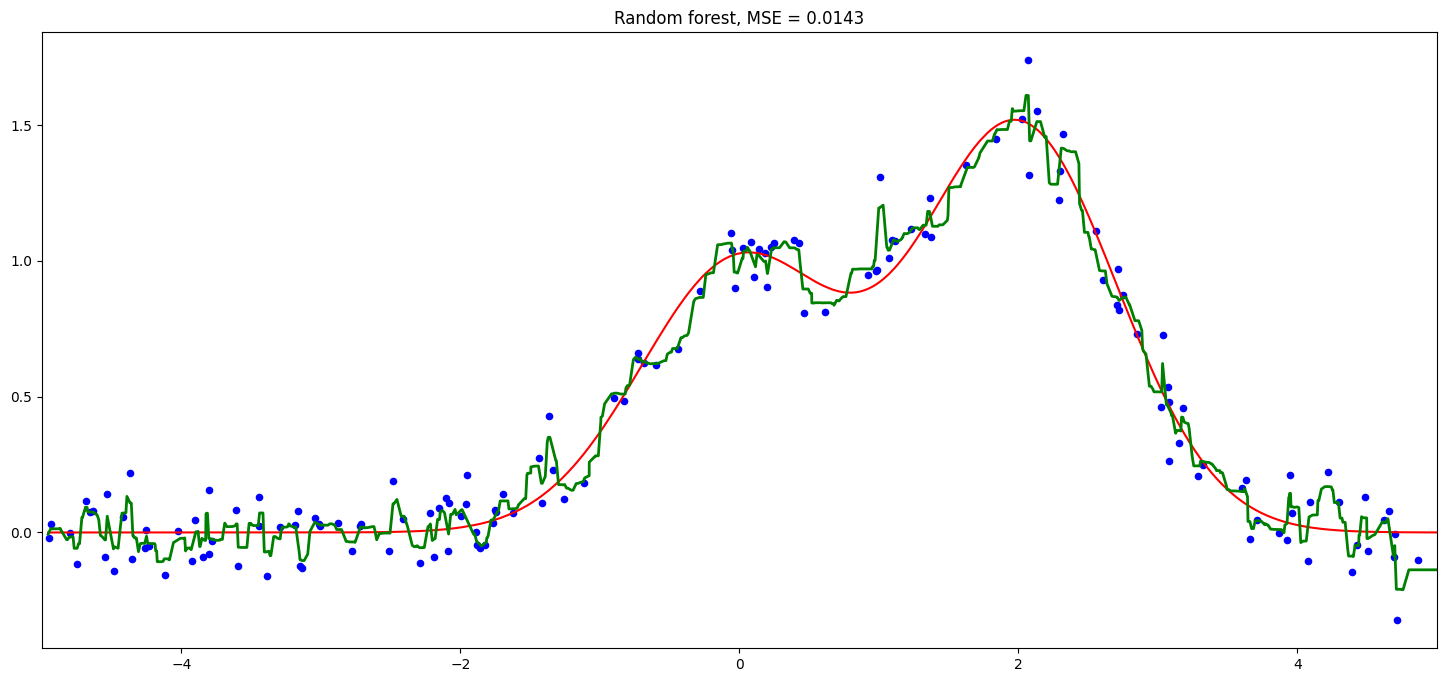

In [28]:
rfr = RandomForestRegressor(n_estimators=1000, random_state=42).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
mse_rf = np.mean((y_test - rf_predict) ** 2)
plt.title("Random forest, MSE = %.4f" % mse_rf)
plt.show()

<a id="bagging"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 8</span>
  <h2> 🧺 Bagging vs Random Forest</h2>
</div>

Random Forest is closely related to **Bagging**, but the way feature randomness is introduced is different.

<div style="overflow:hidden;border-radius:8px;border:1px solid #4a0080;margin:18px 0;">
<table style="width:100%;border-collapse:collapse;font-size:12px;">
  <tr style="background:#2d0050;">
    <th style="padding:9px 12px;color:#a855f7;text-align:left;">Method</th>
    <th style="padding:9px 12px;color:#a855f7;">Bootstrap rows</th>
    <th style="padding:9px 12px;color:#a855f7;">Feature randomness</th>
    <th style="padding:9px 12px;color:#a855f7;text-align:left;">Where it happens</th>
  </tr>
  <tr style="border-bottom:1px solid #4a0080;">
    <td style="padding:8px 12px;color:#f0e6ff;font-weight:700;">Bagging</td>
    <td style="padding:8px 12px;color:#d8b4fe;text-align:center;">✅</td>
    <td style="padding:8px 12px;color:#d8b4fe;text-align:center;">Optional</td>
    <td style="padding:8px 12px;color:#d8b4fe;">Feature subset can be sampled for a base estimator</td>
  </tr>
  <tr>
    <td style="padding:8px 12px;color:#f0e6ff;font-weight:700;">Random Forest</td>
    <td style="padding:8px 12px;color:#d8b4fe;text-align:center;">✅</td>
    <td style="padding:8px 12px;color:#d8b4fe;text-align:center;">✅</td>
    <td style="padding:8px 12px;color:#d8b4fe;">Random subset considered at each tree split</td>
  </tr>
</table>
</div>

### Why the code uses `max_features`

The `BaggingClassifier` below is given `max_features=2`, so it also demonstrates feature subsampling. The important Random Forest distinction is **when** feature selection happens: Random Forest applies `max_features` at each split/node of each decision tree.

The two `plot_tree()` cells let you inspect an individual estimator from each ensemble.


In [29]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [30]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.097152,-2.960018,2.128277,1.784581,0.158432,1
1,0.039495,-0.307938,0.644186,1.893369,2.695362,1
2,-0.010265,-0.493893,-0.175628,0.976279,0.323424,1
3,-0.482940,-0.144474,-0.696371,-0.385395,1.358254,0
4,-2.429468,-2.591960,-1.663086,-2.851990,-1.194906,0


In [31]:
bag = BaggingClassifier(max_features=2)

bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

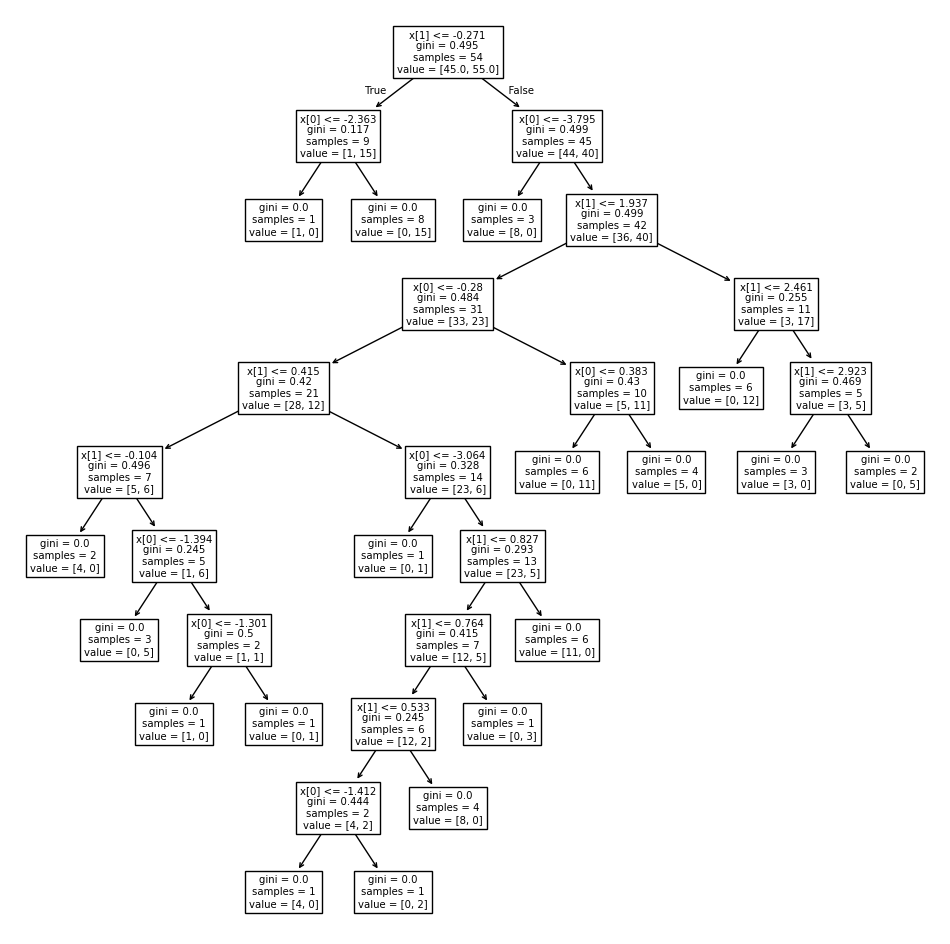

In [32]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [33]:
rf = RandomForestClassifier(max_features=2)

rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

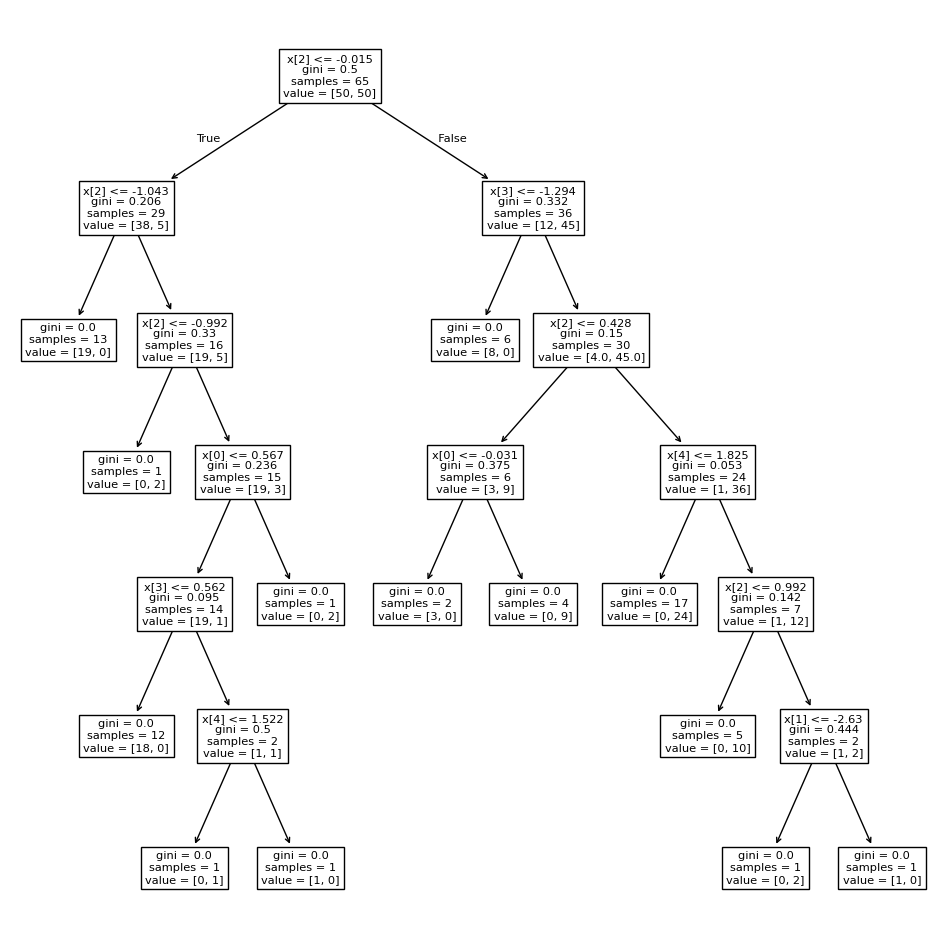

In [34]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()

<a id="tuning"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 9</span>
  <h2> ⚙️ Hyperparameter Tuning</h2>
</div>

We now move from intuition to a real dataset: the **Heart Disease** dataset.

First, we establish a baseline on the same train/test split using four different classifiers.

<div class="rf-grid-2">
  <div class="rf-card"><div style="color:#a855f7;font-weight:700;font-size:13px;">🌲 Random Forest</div><div class="rf-body">Randomised collection of decision trees.</div></div>
  <div class="rf-card"><div style="color:#a855f7;font-weight:700;font-size:13px;">🚀 Gradient Boosting</div><div class="rf-body">Trees are built sequentially to correct previous errors.</div></div>
  <div class="rf-card"><div style="color:#a855f7;font-weight:700;font-size:13px;">📐 SVC</div><div class="rf-body">Margin-based classification, including kernelised decision boundaries.</div></div>
  <div class="rf-card"><div style="color:#a855f7;font-weight:700;font-size:13px;">📊 Logistic Regression</div><div class="rf-body">A linear classification baseline.</div></div>
</div>

<div class="rf-note"><strong style="color:#a855f7;">Interpret scores carefully:</strong> these accuracy values describe this dataset and this particular train/test split. They should not be treated as universal rankings of the algorithms.</div>

### Important Random Forest hyperparameters

| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_features` | Number/fraction of features considered at each split |
| `max_depth` | Maximum depth allowed for each tree |
| `max_samples` | Number/fraction of training samples used per tree |
| `min_samples_split` | Minimum samples required to split a node |
| `min_samples_leaf` | Minimum samples allowed in a leaf |
| `bootstrap` | Whether bootstrap samples are used |


In [35]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [36]:
X = df.drop(columns={"target"})
y = df.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [37]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()
lr = LogisticRegression(max_iter=1000)

In [38]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [39]:
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)
accuracy_score(y_test,y_pred)

0.9317073170731708

In [40]:
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test,y_pred)

0.6829268292682927

In [41]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.7951219512195122


<div class="rf-note">
  <strong style="color:#a855f7;">📊 Reading the benchmark:</strong>
  In the current notebook run, `RandomForestClassifier` produced the highest test accuracy among the four baseline models shown above.
  That result is specific to this dataset and this train/test split, so it should not be treated as a universal ranking of classifiers.
</div>


In [42]:
rf = RandomForestClassifier(max_samples=0.75, random_state=42)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [43]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(rf,X,y,cv=10,scoring='accuracy'))

np.float64(0.9941462021701885)

<a id="grid"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 10</span>
  <h2> 🧮 GridSearchCV</h2>
</div>

`GridSearchCV` evaluates every combination in a predefined grid and uses cross-validation to compare them.

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">✅ Systematic</div>
    <div class="rf-body">Every listed parameter combination is tested.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">⚠️ Can get expensive</div>
    <div class="rf-body">The number of model fits grows with the size of the search grid and the number of cross-validation folds.</div>
  </div>
</div>

This search explores:

`n_estimators` · `max_features` · `max_depth` · `max_samples`

<div class="rf-note"><strong style="color:#a855f7;">Data-splitting rule →</strong> the search is fitted on <code>X_train, y_train</code>. Keep <code>X_test, y_test</code> untouched for the final evaluation.</div>


In [44]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

In [45]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }

In [46]:
rf = RandomForestClassifier()

from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf, 
                       param_grid = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=60; total time=   0.2s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=100; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=120; total time=   0.4s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=120; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=60; total time=   0.2s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=100; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=120; total time=   0.4s
[CV] END max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=20; total time=   0.1s

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [47]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 0.75,
 'n_estimators': 60}

In [48]:
rf_grid.best_score_

np.float64(0.9841463414634146)

<a id="random-search"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 11</span>
  <h2> 🎯 RandomizedSearchCV</h2>
</div>

`RandomizedSearchCV` samples a fixed number of candidate combinations instead of evaluating the entire Cartesian product.

That becomes useful when the hyperparameter space is large.

<div class="rf-card">
  <div class="rf-kicker">A key practical detail</div>
  <div class="rf-body">
    Search spaces should contain <strong style="color:#f0e6ff;">valid parameter combinations</strong>. In Random Forest, <code>max_samples</code> is tied to bootstrap sampling, so the refined search below avoids pairing an incompatible <code>max_samples</code> value with <code>bootstrap=False</code>.
  </div>
</div>


In [49]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,None]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

In [50]:
# Valid parameter spaces for the two bootstrap settings
n_estimators = [20, 60, 100, 120]
max_features = [0.2, 0.6, 1.0]
max_depth = [2, 8, None]
max_samples_bootstrap = [0.5, 0.75, 1.0]
min_samples_split = [2, 5]
min_samples_leaf = [1, 2]

param_distributions = [
    {
        "n_estimators": n_estimators,
        "max_features": max_features,
        "max_depth": max_depth,
        "max_samples": max_samples_bootstrap,
        "bootstrap": [True],
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
    },
    {
        "n_estimators": n_estimators,
        "max_features": max_features,
        "max_depth": max_depth,
        "max_samples": [None],
        "bootstrap": [False],
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
    },
]


In [51]:
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42,
)

rf_random.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions=[{'bootstrap': [True],
                                         'max_depth': [2, 8, None],
                                         'max_features': [0.2, 0.6, 1.0],
                                         'max_samples': [0.5, 0.75, 1.0],
                                         'min_samples_leaf': [1, 2],
                                         'min_samples_split': [2, 5],
                                         'n_estimators': [20, 60, 100, 120]},
                                        {'bootstrap': [False],
                                         'max_depth': [2, 8, None],
                                         'max_features': [0.2, 0.6, 1.0],
                                         'max_samples': [None],
                                         'min_samples_leaf': [1, 2],
                                         'min_samples_split': [2, 5],
                                         'n_estimators': [20, 60, 100, 120]}],
                   random_state=42, verbose=2)

In [52]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': None,
 'max_features': 0.6,
 'max_depth': 8,
 'bootstrap': False}

In [53]:
rf_random.best_score_

np.float64(0.9804878048780488)

<a id="oob"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 12</span>
  <h2> 🪂 OOB Score — Out-of-Bag Evaluation</h2>
</div>

Because bootstrap sampling uses replacement, some training observations are left out of a particular tree's bootstrap sample.

Those observations are **out-of-bag (OOB)** for that tree.

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🌱 Bootstrap sample</div>
    <div class="rf-body">A tree is trained on a resampled version of the training set.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🪂 OOB prediction</div>
    <div class="rf-body">Only trees that did not train on a particular sample contribute to that sample's OOB prediction.</div>
  </div>
</div>

With `oob_score=True`, scikit-learn reports an internal OOB performance estimate.

The next cells compare that estimate with the accuracy on the separate test set.

<div class="rf-note"><strong style="color:#a855f7;">Think of them as two different views:</strong> OOB score comes from bootstrap-held-out observations inside the training process; test accuracy comes from the explicitly held-out test set.</div>


In [54]:
rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train,y_train)

RandomForestClassifier(oob_score=True)

In [55]:
rf.oob_score_

0.9951219512195122

In [56]:
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

<a id="importance"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 13</span>
  <h2> 🧠 Feature Importance Using Random Forest</h2>
</div>

Feature importance is one way to inspect which inputs the trees use most heavily.

The example switches to the **MNIST digit-recognizer** dataset, where each image is represented by **784 pixel features** (`28 × 28`).

The notebook:

1. loads the pixel matrix,
2. trains a Random Forest,
3. reads `feature_importances_`, and
4. reshapes the 784 importance values back into `28 × 28`.

That final heatmap turns model-level importance values into something visually aligned with the original digit image.


In [57]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
X = df.drop(columns=["label"])
y = df.label

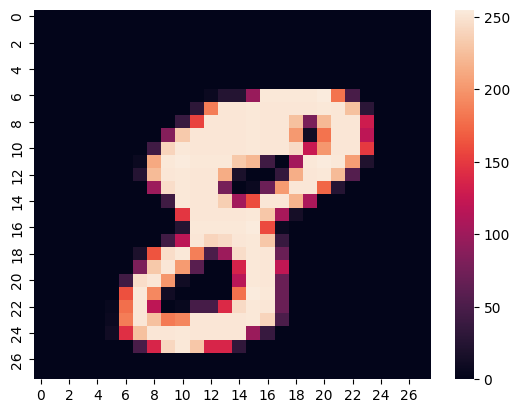

In [59]:
sns.heatmap(X.iloc[10].values.reshape(28,28))
plt.show()

In [60]:
rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [61]:
rf.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.25175862e-07, 5.25783510e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.20748541e-07, 3.77899180e-06, 2.38714778e-06, 1.75058370e-06,
       2.29117887e-06, 3.82537946e-06, 6.22947998e-06, 7.29537757e-06,
       3.47718963e-06, 2.32377665e-06, 1.03204088e-06, 1.00003219e-06,
       0.00000000e+00, 5.15774745e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

<Axes: >

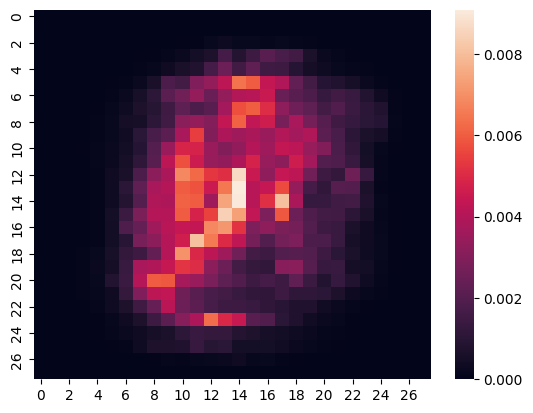

In [62]:
sns.heatmap(rf.feature_importances_.reshape(28,28))

<a id="importance-math"></a>
<div class="rf-wrap rf-section">
  <span class="rf-pill">Section 14</span>
  <h2> 🧮 How Feature Importance Is Calculated</h2>
</div>

For a decision tree, scikit-learn's default `feature_importances_` is based on **impurity reduction**.

For a split, the weighted decrease in impurity can be written as:

<div class="rf-card" style="text-align:center;">
  <div style="color:#f0e6ff;font-family:Georgia,serif;font-size:18px;font-weight:600;">
    ΔI = <span style="color:#a855f7;">I(parent)</span>
    − <span style="color:#a855f7;">w<sub>L</sub>I(left)</span>
    − <span style="color:#a855f7;">w<sub>R</sub>I(right)</span>
  </div>
  <div class="rf-body" style="margin-top:8px;">The child terms are weighted according to how many samples reach each child node.</div>
</div>

A feature receives importance when splits using that feature produce impurity reductions.

### 🔬 The small example

The final cells use only **2 features and 5 samples** so the result stays easy to inspect:

<div class="rf-grid-2">
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🌳 One tree</div>
    <div class="rf-body">Inspect the tree structure and its two feature-importance values.</div>
  </div>
  <div class="rf-card">
    <div style="color:#a855f7;font-weight:700;font-size:13px;">🌲 Small forest</div>
    <div class="rf-body">Compare the individual tree importances with the aggregated Random Forest importance.</div>
  </div>
</div>

The forest combines importance contributions across its trees and normalizes the resulting values so the feature importances sum to approximately **1**.


In [63]:
X,y = make_classification(n_samples=5, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)

In [64]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.875\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

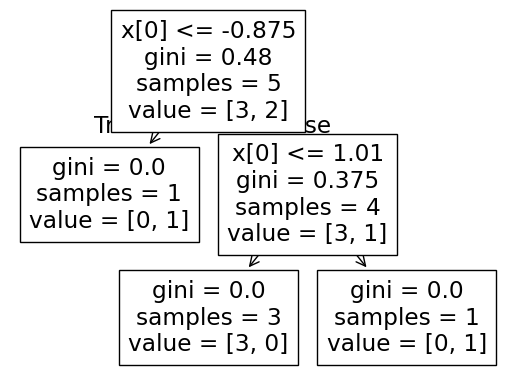

In [65]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [66]:
clf.feature_importances_

array([1., 0.])

In [67]:
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X,y)

RandomForestClassifier(n_estimators=5)

In [68]:
rf.feature_importances_

array([0.525, 0.475])

In [69]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)
print(rf.estimators_[2].feature_importances_)
print(rf.estimators_[3].feature_importances_)
print(rf.estimators_[4].feature_importances_)

[0. 1.]
[1. 0.]
[1. 0.]
[0. 1.]
[0.625 0.375]



<a id="takeaways"></a>
<div class="rf-wrap" style="background:linear-gradient(135deg,#1a0030 0%,#2d0050 100%);border:1px solid #4a0080;border-radius:14px;padding:36px 40px;margin-top:32px;">
  <h2 style="color:#fff;font-size:20px;font-weight:700;margin:0 0 8px 0;">📌 Key Concepts &amp; Takeaways</h2>
  <p style="color:#d8b4fe;font-size:13px;margin:0 0 20px 0;">Everything that matters about Random Forest.</p>

  <div class="rf-grid-2" style="margin-bottom:20px;">
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">🌱 Bootstrap Sampling</div>
      <div class="rf-body">Trees are trained on bootstrap samples, creating different training sets and useful model diversity.</div>
    </div>
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">🎲 Random Features</div>
      <div class="rf-body">A random subset of features is considered at splits, reducing correlation between trees.</div>
    </div>
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">🗳️ Voting / Averaging</div>
      <div class="rf-body">Classification uses aggregated class predictions; regression aggregates numerical predictions.</div>
    </div>
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">🪂 OOB Score</div>
      <div class="rf-body">Out-of-bag samples provide an internal performance estimate when bootstrap sampling is used.</div>
    </div>
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">⚙️ Hyperparameters</div>
      <div class="rf-body"><code>n_estimators</code>, <code>max_features</code>, <code>max_depth</code>, <code>max_samples</code>, and leaf/split constraints control the forest.</div>
    </div>
    <div style="background:rgba(168,85,247,0.08);border:1px solid #4a0080;border-radius:10px;padding:16px 18px;">
      <div style="color:#a855f7;font-weight:700;font-size:13px;margin-bottom:6px;">🧠 Feature Importance</div>
      <div class="rf-body">Impurity-based importance summarizes how much each feature contributes to splits across the forest.</div>
    </div>
  </div>

  <div style="padding-top:14px;border-top:1px solid #4a0080;color:#d8b4fe;font-size:12px;">
    Next → <strong style="color:#a855f7;">continue the ensemble journey with boosting methods such as AdaBoost.</strong>
  </div>
</div>
